
--- Processing AAPL ---
Saved AAPL_historical.csv

--- Processing MSFT ---
Saved MSFT_historical.csv


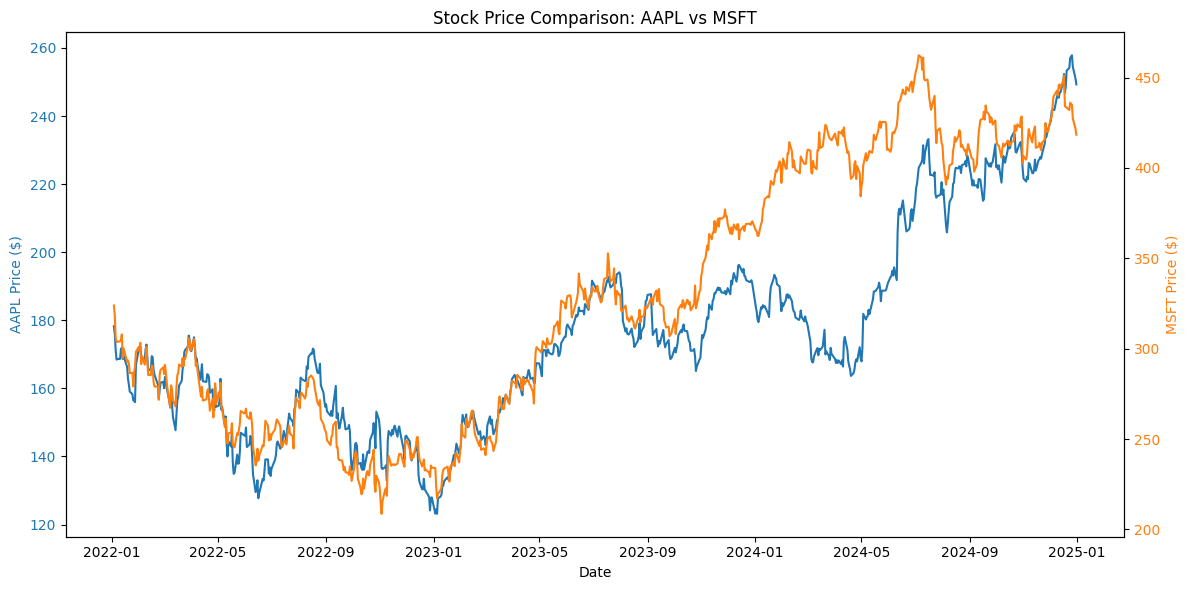

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from utils import ForecastingMetrics
import warnings
warnings.filterwarnings("ignore")


FORECAST_DAYS = 60
START_DATE = '2022-01-01'
END_DATE = '2025-01-01'
INITIAL_LAGS = 5 # To be checked

def get_and_clean_stock_data(ticker_symbol, save_csv=True):
    print(f"\n--- Processing {ticker_symbol} ---")
    
    # Ingestion
    df = yf.download(ticker_symbol, start=START_DATE, end=END_DATE, progress=False)
    
    if df.empty:
        raise ValueError(f"No data found for {ticker_symbol}.")

    # Flatten MultiIndex if necessary
    if isinstance(df.columns, pd.MultiIndex):
        try:
            if 'Close' in df.columns.get_level_values(0):
                df = df.xs('Close', axis=1, level=0, drop_level=True)
            elif 'Close' in df.columns.get_level_values(1):
                df = df.xs('Close', axis=1, level=1, drop_level=True)
        except KeyError:
            pass
            
    if 'Close' in df.columns:
        data = df[['Close']].copy()
    else:
        data = df.iloc[:, 0].to_frame(name='Close')

    # Forward fill missing values
    if data.isnull().values.any():
        print(f"Found {data.isnull().sum()} missing values. Filling...")
        data = data.ffill().bfill()
        
        
    if save_csv:
        filename = f"{ticker_symbol}_historical.csv"
        data.to_csv(filename)
        print(f"Saved {filename}")
    
    return data

# Plot stocks data
def plot_two_stocks(data1, name1, data2, name2):
    fig, ax1 = plt.subplots(figsize=(12, 6))

    color = 'tab:blue'
    ax1.set_xlabel('Date')
    ax1.set_ylabel(f'{name1} Price ($)', color=color)
    ax1.plot(data1.index, data1['Close'], color=color, label=name1)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  
    color = 'tab:orange'
    ax2.set_ylabel(f'{name2} Price ($)', color=color)
    ax2.plot(data2.index, data2['Close'], color=color, label=name2)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Stock Price Comparison: {name1} vs {name2}')
    fig.tight_layout()
    plt.show()


MY_STOCKS = ['AAPL', 'MSFT'] 
stock_data_store = {}

for ticker in MY_STOCKS:
    stock_data_store[ticker] = get_and_clean_stock_data(ticker)

plot_two_stocks(
    stock_data_store[MY_STOCKS[0]], MY_STOCKS[0],
    stock_data_store[MY_STOCKS[1]], MY_STOCKS[1]
)

# Tset (dont mind)

In [35]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import scipy.optimize as sco

# Custom Modules
from backtest import Backtest
from utils import PortfolioEvaluator, TradingMetrics

import warnings
warnings.filterwarnings("ignore")

# --- HACKATHON CONFIGURATION ---
my_stocks = ['AAPL', 'MSFT'] 

start_date = '2022-01-01'
end_date = '2025-01-01'
forecast_days = 60

# SEASONALITY: 5 days (Weekly trading cycle)
seasonal_period = 5 

# LAGS: Fixed at 60 (approx. 3 months/1 quarter of history)
lags = 60            
capital = 10000

In [36]:
def get_data(ticker):
    print(f"Fetching data for {ticker}...")
    df = yf.download(ticker, start=start_date, end=end_date, progress=False)
    
    if isinstance(df.columns, pd.MultiIndex):
        df = df.xs(ticker, axis=1, level=1)
        
    # STRATEGY: ORDINAL TIME
    # We strictly drop missing data (weekends/holidays).
    df = df.dropna()
    
    return df[['Close']]

stock_data = {ticker: get_data(ticker) for ticker in my_stocks}
print("Data ingestion complete (Ordinal Trading Days).")

Fetching data for AAPL...
Fetching data for MSFT...
Data ingestion complete (Ordinal Trading Days).


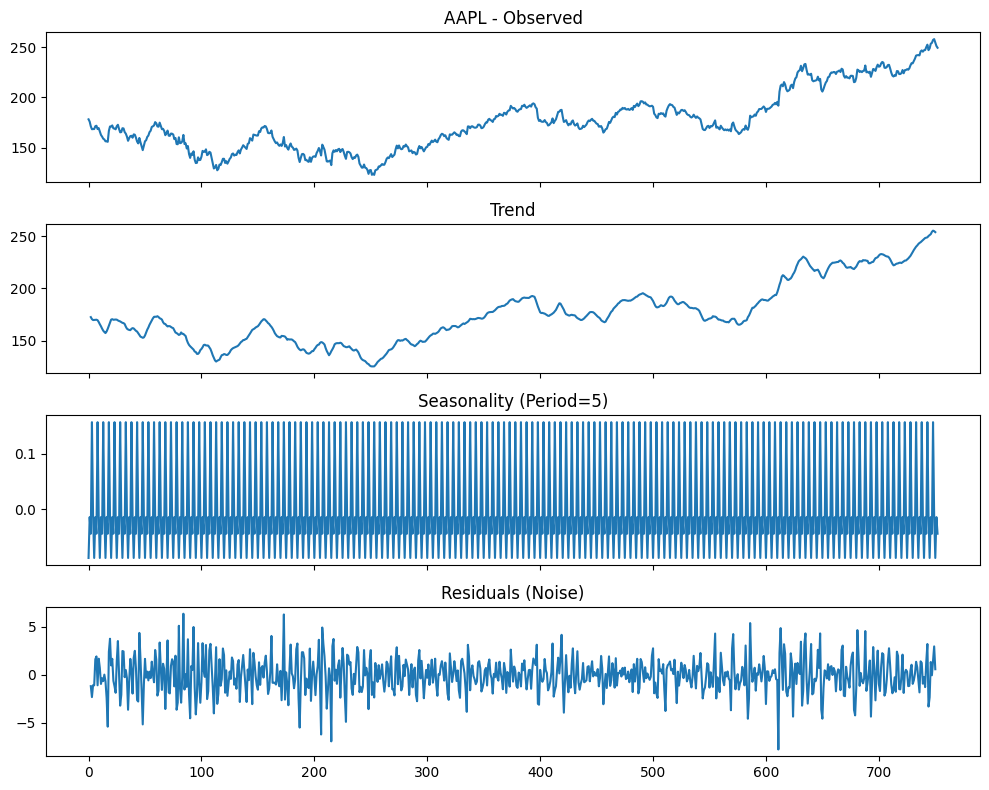


--- Stationarity Tests for AAPL Residuals ---
ADF p-value:  0.0000 (Stationary)
KPSS p-value: 0.0521 (Stationary)

--- ACF/PACF Diagnostics for AAPL ---


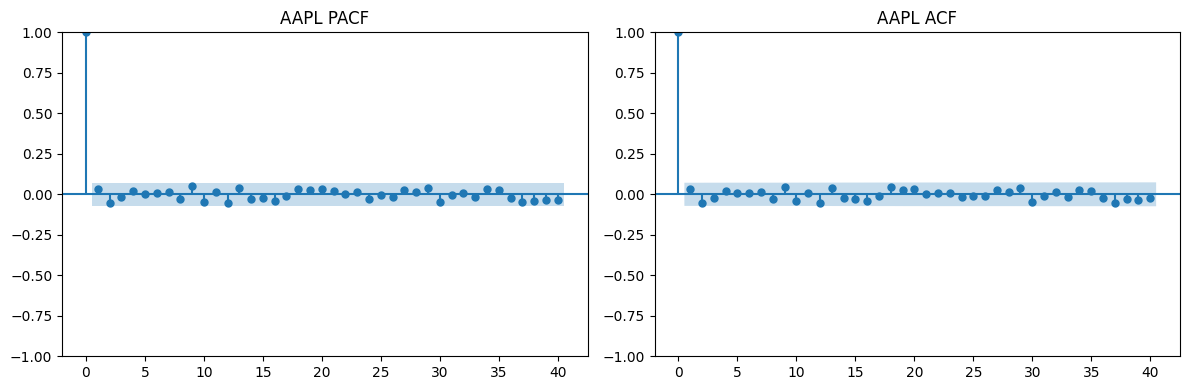

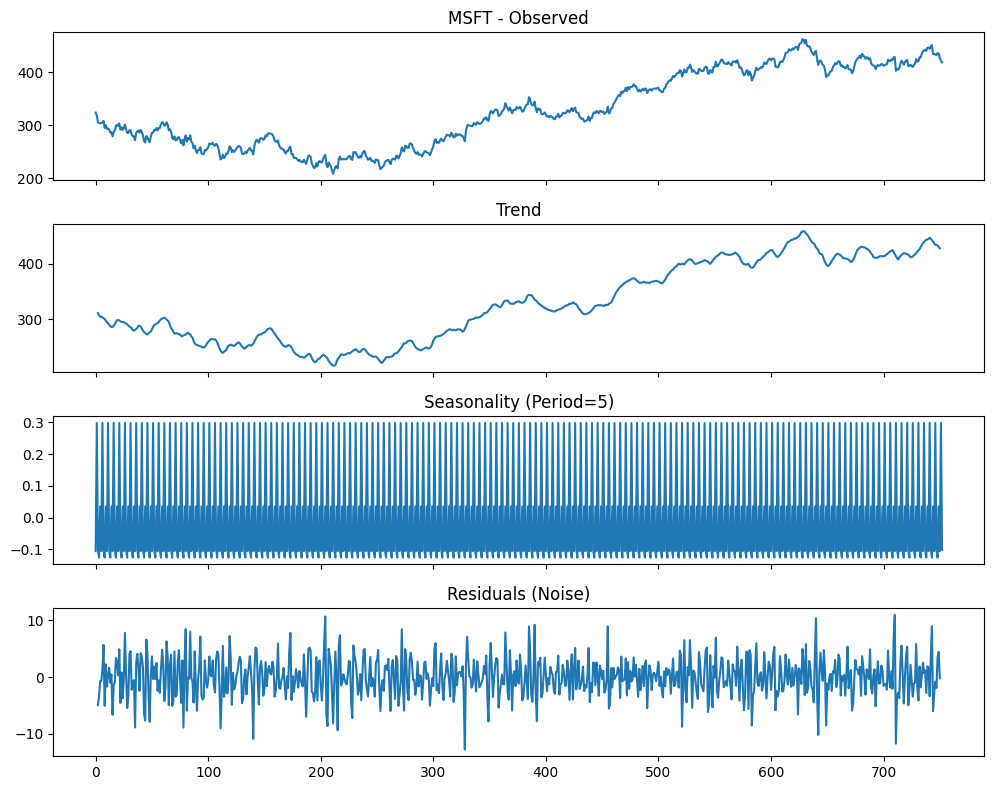


--- Stationarity Tests for MSFT Residuals ---
ADF p-value:  0.0000 (Stationary)
KPSS p-value: 0.0417 (Non-Stationary)

--- ACF/PACF Diagnostics for MSFT ---


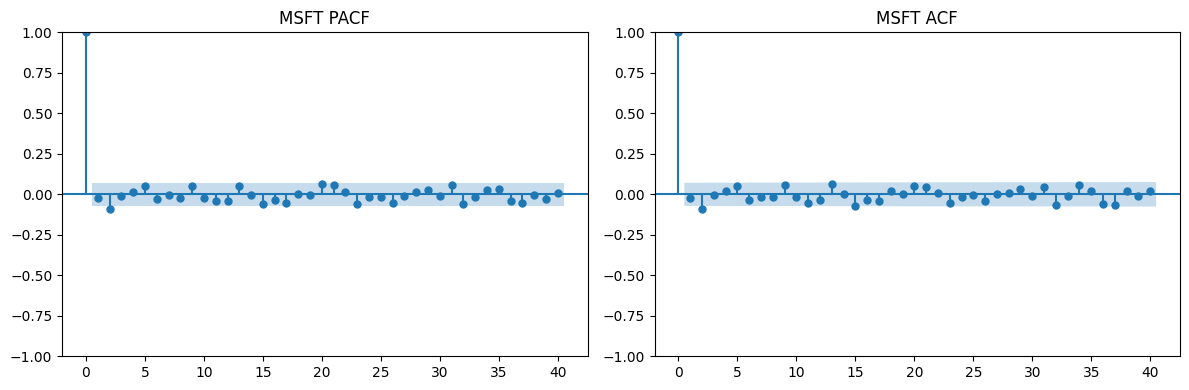

In [37]:
def diagnose_stock(ticker, df, period):
    series = df['Close']
    
    # Decompose
    decomp = seasonal_decompose(series.values, model='additive', period=period)
    
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
    axes[0].plot(series.values); axes[0].set_title(f'{ticker} - Observed')
    axes[1].plot(decomp.trend); axes[1].set_title('Trend')
    axes[2].plot(decomp.seasonal); axes[2].set_title(f'Seasonality (Period={period})')
    axes[3].plot(decomp.resid); axes[3].set_title('Residuals (Noise)')
    plt.tight_layout()
    plt.show()
    
    # Stationarity Tests on Residuals
    resid = pd.Series(decomp.resid).dropna()
    print(f"\n--- Stationarity Tests for {ticker} Residuals ---")
    
    adf_p = adfuller(resid)[1]
    is_adf_stat = adf_p < 0.05
    print(f"ADF p-value:  {adf_p:.4f} ({'Stationary' if is_adf_stat else 'Non-Stationary'})")
    
    kpss_p = kpss(resid, regression='c', nlags="auto")[1]
    is_kpss_stat = kpss_p > 0.05
    print(f"KPSS p-value: {kpss_p:.4f} ({'Stationary' if is_kpss_stat else 'Non-Stationary'})")

    if is_kpss_stat and not is_adf_stat:
        print(f"⚠️ CAUTION: Conflict detected. Visual inspection recommended.")

    print(f"\n--- ACF/PACF Diagnostics for {ticker} ---")
    sa_series = pd.Series(series.values - decomp.seasonal)
    diff_sa_series = sa_series.diff().dropna()

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    plot_pacf(diff_sa_series, lags=40, ax=ax[0], method='ywm')
    ax[0].set_title(f"{ticker} PACF")
    plot_acf(diff_sa_series, lags=40, ax=ax[1])
    ax[1].set_title(f"{ticker} ACF")
    plt.tight_layout()
    plt.show()

for ticker in my_stocks:
    diagnose_stock(ticker, stock_data[ticker], seasonal_period)

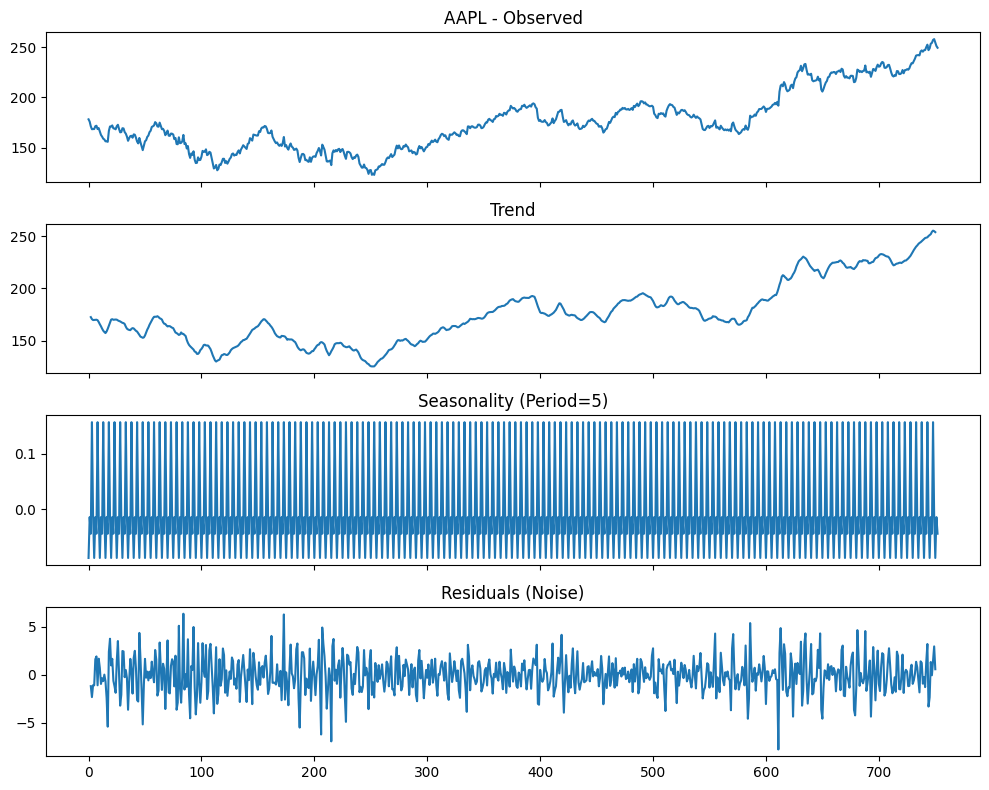


--- Stationarity Tests for AAPL Residuals ---
ADF p-value:  0.0000 (Stationary)
KPSS p-value: 0.0521 (Stationary)
⚠️ Conflict detected. Use caution and inspect visually.

--- Stationarity Tests for AAPL Seasonally Adjusted Series (1st Diff) ---
ADF p-value:  0.0000 (Stationary)
KPSS p-value: 0.1000 (Stationary)

--- ACF/PACF Diagnostics for AAPL (1st Difference of Seasonally Adjusted) ---


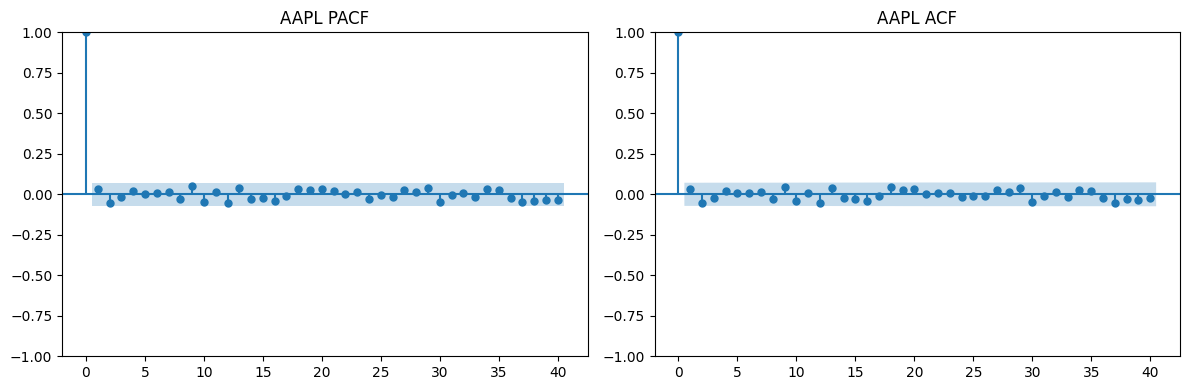

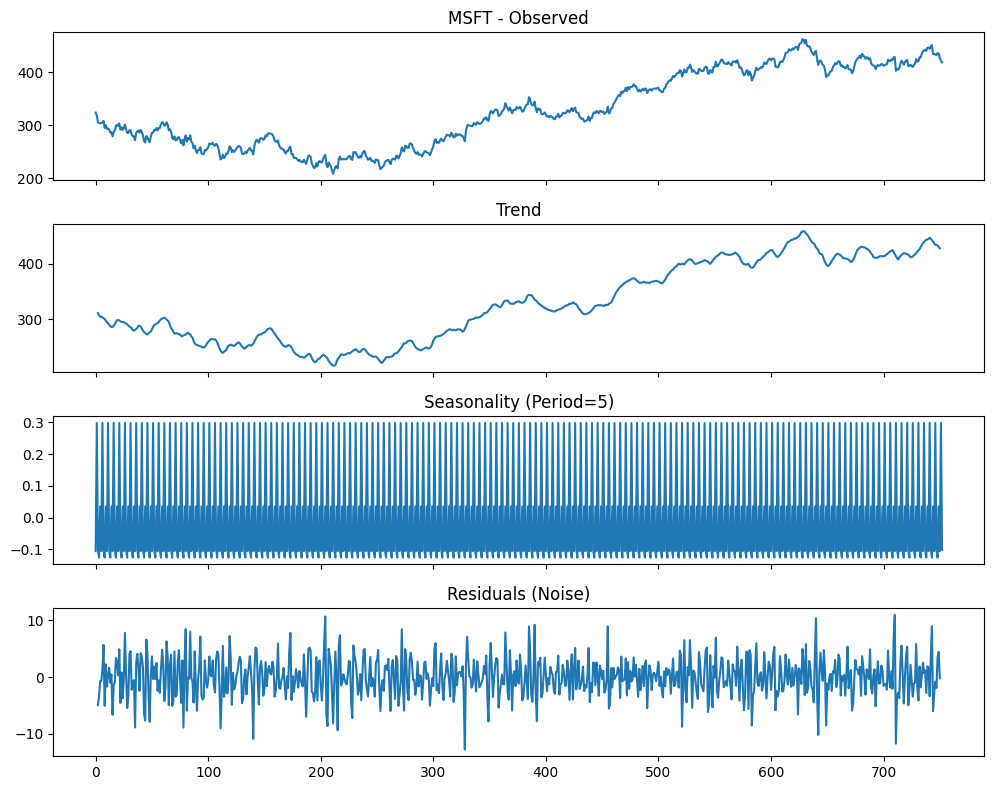


--- Stationarity Tests for MSFT Residuals ---
ADF p-value:  0.0000 (Stationary)
KPSS p-value: 0.0417 (Non-Stationary)
✅ Both tests agree: series is stationary.

--- Stationarity Tests for MSFT Seasonally Adjusted Series (1st Diff) ---
ADF p-value:  0.0000 (Stationary)
KPSS p-value: 0.1000 (Stationary)

--- ACF/PACF Diagnostics for MSFT (1st Difference of Seasonally Adjusted) ---


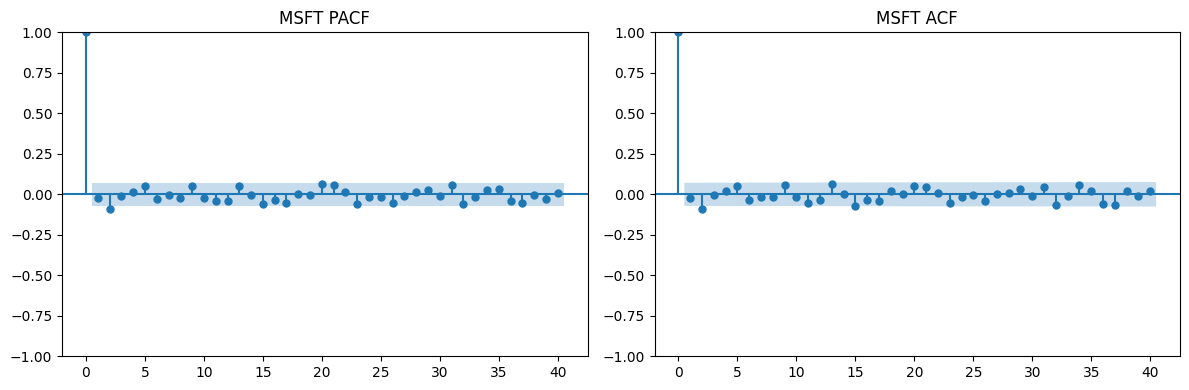

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def diagnose_stock(ticker, df, period):
    series = df['Close']
    
    # 1. Seasonal Decomposition
    decomp = seasonal_decompose(series.values, model='additive', period=period)
    
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
    axes[0].plot(series.values); axes[0].set_title(f'{ticker} - Observed')
    axes[1].plot(decomp.trend); axes[1].set_title('Trend')
    axes[2].plot(decomp.seasonal); axes[2].set_title(f'Seasonality (Period={period})')
    axes[3].plot(decomp.resid); axes[3].set_title('Residuals (Noise)')
    plt.tight_layout()
    plt.show()

    # 2. Residuals Stationarity Test
    resid = pd.Series(decomp.resid).dropna()
    print(f"\n--- Stationarity Tests for {ticker} Residuals ---")
    
    adf_p = adfuller(resid)[1]
    kpss_p = kpss(resid, regression='c', nlags="auto")[1]
    print(f"ADF p-value:  {adf_p:.4f} ({'Stationary' if adf_p < 0.05 else 'Non-Stationary'})")
    print(f"KPSS p-value: {kpss_p:.4f} ({'Stationary' if kpss_p > 0.05 else 'Non-Stationary'})")
    
    if (kpss_p > 0.05) and (adf_p >= 0.05):
        print(f"⚠️ Both tests indicate non-stationarity.")
    elif (kpss_p < 0.05) and (adf_p < 0.05):
        print(f"✅ Both tests agree: series is stationary.")
    else:
        print(f"⚠️ Conflict detected. Use caution and inspect visually.")

    # 3. Stationarity of Seasonally Adjusted Series
    sa_series = pd.Series(series.values - decomp.seasonal).dropna()
    diff_sa_series = sa_series.diff().dropna()

    print(f"\n--- Stationarity Tests for {ticker} Seasonally Adjusted Series (1st Diff) ---")
    adf_p_sa = adfuller(diff_sa_series)[1]
    kpss_p_sa = kpss(diff_sa_series, regression='c', nlags="auto")[1]
    print(f"ADF p-value:  {adf_p_sa:.4f} ({'Stationary' if adf_p_sa < 0.05 else 'Non-Stationary'})")
    print(f"KPSS p-value: {kpss_p_sa:.4f} ({'Stationary' if kpss_p_sa > 0.05 else 'Non-Stationary'})")

    # 4. ACF/PACF of Differenced Seasonally Adjusted Series
    print(f"\n--- ACF/PACF Diagnostics for {ticker} (1st Difference of Seasonally Adjusted) ---")
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    plot_pacf(diff_sa_series, lags=40, ax=ax[0], method='ywm')
    ax[0].set_title(f"{ticker} PACF")
    plot_acf(diff_sa_series, lags=40, ax=ax[1])
    ax[1].set_title(f"{ticker} ACF")
    plt.tight_layout()
    plt.show()

for ticker in my_stocks:
    diagnose_stock(ticker, stock_data[ticker], seasonal_period)


In [42]:
def make_lagged(series, n_lags):
    s = pd.Series(series).reset_index(drop=True)
    df = pd.DataFrame({'y': s})
    for i in range(1, n_lags+1):
        df[f'lag_{i}'] = s.shift(i)
    return df.dropna()

def recursive_forecast(last_window, model, steps, feature_names):
    preds = []
    current_window = list(last_window)
    for _ in range(steps):
        input_df = pd.DataFrame([current_window], columns=feature_names)
        pred = model.predict(input_df)[0]
        preds.append(pred)
        current_window.pop(0)
        current_window.append(pred)
    return np.array(preds)

def train_and_validate(ticker, df, period, n_lags, steps):
    print(f"\n=== Modeling {ticker} (Ordinal: Trend + Seasonal + Residuals) ===")
    series = df['Close']
    
    # --- STEP 1: DECOMPOSE ---
    decomp = seasonal_decompose(series.values, model='additive', period=period)
    
    # 1. Seasonal
    seasonal = pd.Series(decomp.seasonal).dropna()
    seasonal_cycle = seasonal.iloc[-period:].values
    
    # 2. Trend (Linear Reg)
    time_idx = np.arange(len(series)).reshape(-1, 1)
    trend_model = LinearRegression()
    trend_model.fit(time_idx, series.values)
    trend_line = trend_model.predict(time_idx)
    
    # 3. Residuals
    residuals = series.values - trend_line - decomp.seasonal
    residuals = pd.Series(residuals).fillna(0)

    # --- STEP 2: SPLIT ---
    split_idx = len(series) - steps
    df_lagged = make_lagged(residuals, n_lags)
    X = df_lagged.drop(columns='y')
    y = df_lagged['y']
    
    train_size = split_idx - n_lags
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:train_size+steps]
    y_train = y.iloc[:train_size]
    
    # --- STEP 3: FORECAST COMPONENTS ---
    future_time = np.arange(len(series), len(series) + steps).reshape(-1, 1)
    future_trend = trend_model.predict(future_time)
    future_seasonal = np.tile(seasonal_cycle, int(np.ceil(steps/period)))[:steps]
    
    # --- STEP 4: MODEL RESIDUALS ---
    preds = {}
    
    # Model 1: ARIMA (High Order for Momentum)
    try:
        # (5,0,5) forces it to look back 5 days to capture momentum
        arima = ARIMA(residuals.iloc[:split_idx].values, order=(5,0,5)).fit() 
        p_resid_arima = arima.forecast(steps=steps)
        preds['ARIMA'] = future_trend + future_seasonal + p_resid_arima
    except:
        preds['ARIMA'] = future_trend + future_seasonal 
        
    # Model 2: LinReg
    lr_resid = LinearRegression().fit(X_train, y_train)
    p_resid_lr = recursive_forecast(residuals.iloc[split_idx-n_lags:split_idx].values, lr_resid, steps, X_train.columns)
    preds['LinReg'] = future_trend + future_seasonal + p_resid_lr
    
    # Model 3: Random Forest
    rf_resid = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42).fit(X_train, y_train)
    p_resid_rf = recursive_forecast(residuals.iloc[split_idx-n_lags:split_idx].values, rf_resid, steps, X_train.columns)
    preds['RF'] = future_trend + future_seasonal + p_resid_rf
    
    # --- STEP 5: EVALUATE ---
    actual = series.iloc[split_idx:].values
    scores = {k: mean_squared_error(actual, v) for k, v in preds.items()}
    winner = min(scores, key=scores.get)
    
    print(f"  > Winner: {winner} (MSE: {scores[winner]:.4f})")
    
    return {
        'winner': winner,
        'preds': preds,
        'actual': actual,
        'test_index': series.index[split_idx:]
    }

results = {stock: train_and_validate(stock, stock_data[stock], seasonal_period, lags, forecast_days) for stock in my_stocks}


=== Modeling AAPL (Ordinal: Trend + Seasonal + Residuals) ===
  > Winner: LinReg (MSE: 114.6716)

=== Modeling MSFT (Ordinal: Trend + Seasonal + Residuals) ===
  > Winner: ARIMA (MSE: 358.7859)


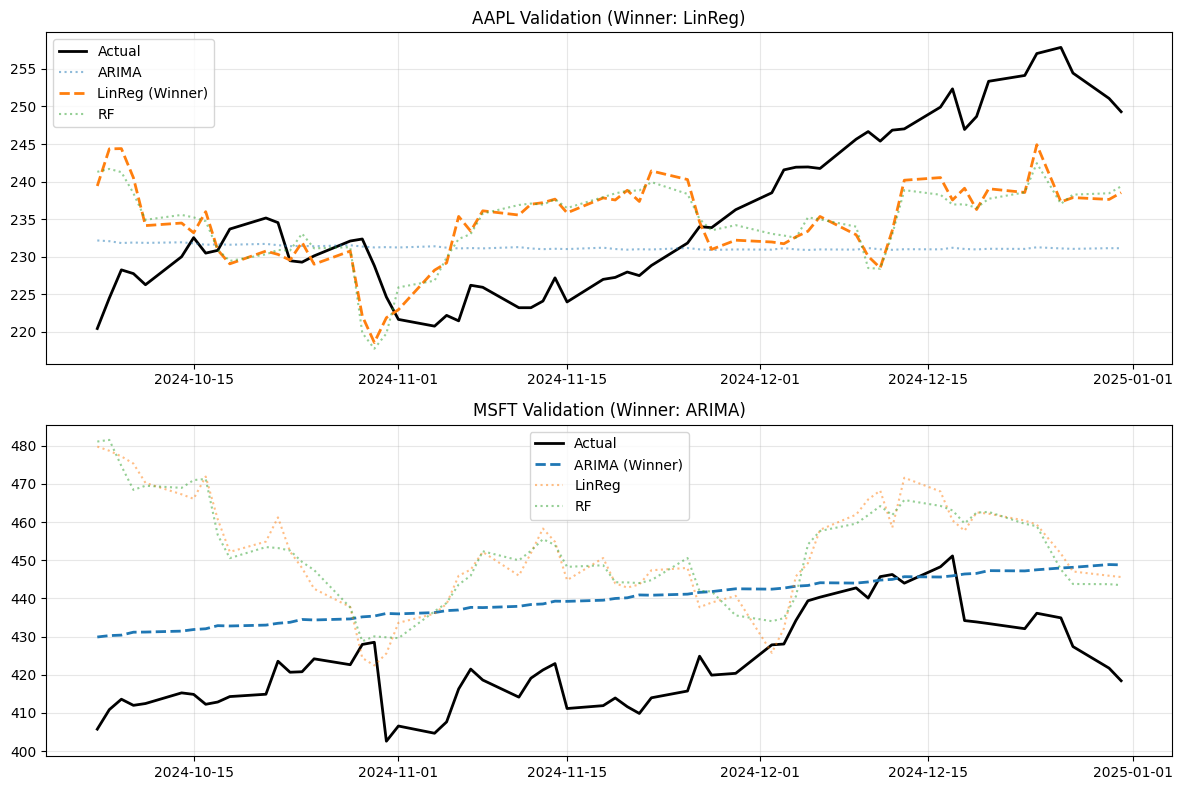

In [43]:
fig, axes = plt.subplots(len(my_stocks), 1, figsize=(12, 4 * len(my_stocks)))
if len(my_stocks) == 1: axes = [axes]

for ax, stock in zip(axes, my_stocks):
    res = results[stock]
    ax.plot(res['test_index'], res['actual'], label='Actual', color='black', linewidth=2)
    for name, p in res['preds'].items():
        if name == res['winner']:
            ax.plot(res['test_index'], p, label=f"{name} (Winner)", linestyle='--', linewidth=2)
        else:
            ax.plot(res['test_index'], p, label=name, linestyle=':', alpha=0.5)
    ax.set_title(f"{stock} Validation (Winner: {res['winner']})")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


 FINAL TRADING REPORT (Phantom Troupe) 

1. OPTIMAL MARKOWITZ ALLOCATION:
   - AAPL: 11.43%
   - MSFT: 88.57%
PORTFOLIO EVALUATION REPORT

INDIVIDUAL STOCK PERFORMANCE:
--------------------------------------------------------------------------------
Stock    Model           Return%      Sharpe     MaxDD%     WinRate%   PF        
--------------------------------------------------------------------------------
AAPL     LinReg              13.14%      0.31     -1.40%   100.00%      inf
MSFT     ARIMA                6.74%      0.09     -5.91%   100.00%      inf
--------------------------------------------------------------------------------

Initial Capital:       $10,000.00
Final Portfolio Value: $10,736.96
Total Profit:          $736.96
Total Return:          7.37%
Sharpe Ratio:          0.11
Maximum Drawdown:      -5.22%
Volatility:            1.09%


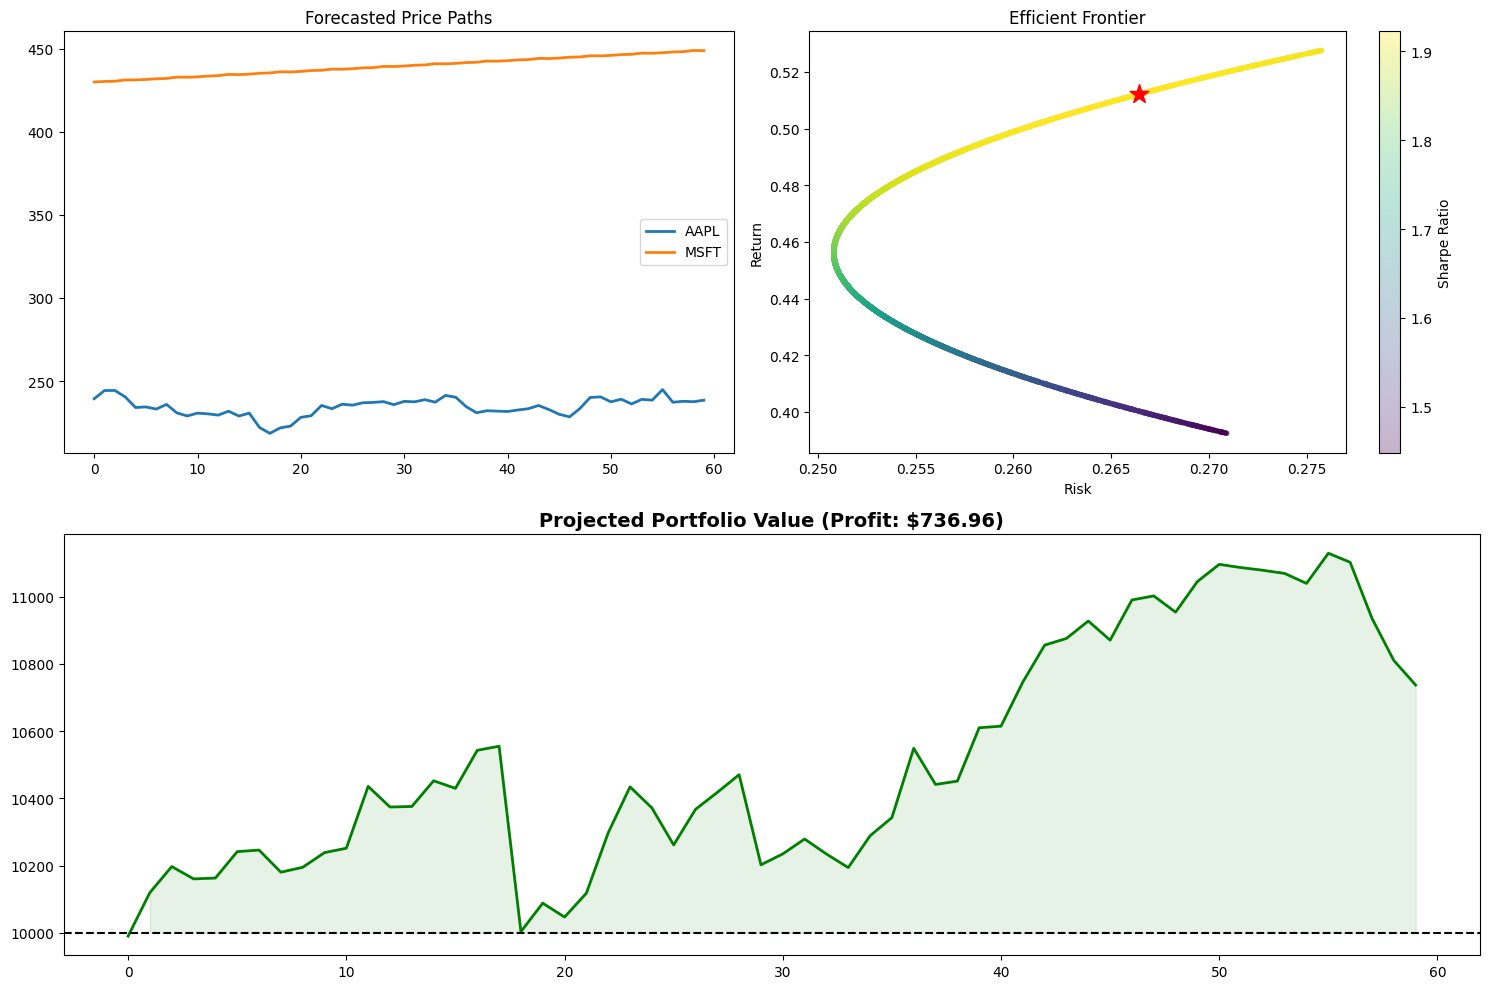


>>> ESTIMATED TOTAL PROFIT: $736.96


In [44]:
def get_scalar(data_obj, index_pos):
    """Robust extractor to handle pandas/numpy shape mismatches."""
    if hasattr(data_obj, 'values'):
        data_obj = data_obj.values
    return np.array(data_obj).flatten()[index_pos]

def get_optimal_weights(results, stocks_list, data_dict):
    # 1. Expected Returns (From Best Forecasts)
    expected_returns = []
    for ticker in stocks_list:
        actuals = results[ticker]['actual']
        preds = results[ticker]['preds'][results[ticker]['winner']]
        
        start_price = get_scalar(actuals, 0)
        end_price = get_scalar(preds, -1)
        
        roi = (end_price - start_price) / start_price
        n_days = len(actuals) if hasattr(actuals, '__len__') else 60
        annualized_roi = (1 + roi) ** (252 / n_days) - 1
        expected_returns.append(annualized_roi)
    
    expected_returns = np.array(expected_returns)
    
    # 2. Covariance (From FULL History)
    price_dict = {t: data_dict[t]['Close'].values.flatten() for t in stocks_list}
    price_df = pd.DataFrame(price_dict)
    cov_matrix = price_df.pct_change().dropna().cov() * 252 

    # 3. Maximize Sharpe Ratio
    num_assets = len(stocks_list)
    def neg_sharpe_ratio(weights):
        p_ret = np.sum(expected_returns * weights)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        return -(p_ret - 0.02) / p_vol 

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0.0, 1.0) for _ in range(num_assets))
    
    result = sco.minimize(neg_sharpe_ratio, [1./num_assets]*num_assets, 
                          method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x, expected_returns, cov_matrix

def generate_final_report(results, stocks_list, data_dict, initial_capital=10000):
    print(f"\n{'='*50}\n FINAL TRADING REPORT (Phantom Troupe) \n{'='*50}")
    
    # Optimize
    opt_weights, exp_rets, cov_mat = get_optimal_weights(results, stocks_list, data_dict)
    allocation_dict = {ticker: round(weight, 4) for ticker, weight in zip(stocks_list, opt_weights)}
    
    print("\n1. OPTIMAL MARKOWITZ ALLOCATION:")
    for ticker, weight in allocation_dict.items():
        print(f"   - {ticker}: {weight*100:.2f}%")

    # Evaluate
    evaluator = PortfolioEvaluator(starting_capital=initial_capital, allocation=allocation_dict)
    for ticker in stocks_list:
        winner = results[ticker]['winner']
        bt = Backtest(starting_capital=initial_capital)
        bt.run_strategy(results[ticker]['actual'], results[ticker]['preds'][winner], threshold=0.01)
        evaluator.add_stock(ticker, bt, winner)

    evaluator.show_report()
    
    # Plots
    metrics = evaluator.compute_portfolio_performance()
    profit = metrics['profit_$']
    
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2)
    
    # A. Forecasts
    ax1 = fig.add_subplot(gs[0, 0])
    for ticker in stocks_list:
        winner = results[ticker]['winner']
        preds = results[ticker]['preds'][winner]
        ax1.plot(preds, label=f"{ticker}", linewidth=2)
    ax1.set_title("Forecasted Price Paths")
    ax1.legend()
    
    # B. Frontier
    ax2 = fig.add_subplot(gs[0, 1])
    num_portfolios = 10000 
    p_rets, p_vols = [], []
    for _ in range(num_portfolios):
        weights = np.random.random(len(stocks_list))
        weights /= np.sum(weights)
        p_ret = np.sum(exp_rets * weights)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(cov_mat, weights)))
        p_rets.append(p_ret)
        p_vols.append(p_vol)
    
    sc = ax2.scatter(p_vols, p_rets, c=np.array(p_rets)/np.array(p_vols), marker='.', cmap='viridis', alpha=0.3)
    opt_ret = np.sum(exp_rets * opt_weights)
    opt_vol = np.sqrt(np.dot(opt_weights.T, np.dot(cov_mat, opt_weights)))
    ax2.scatter(opt_vol, opt_ret, marker='*', color='red', s=200, label='Optimal Portfolio')
    ax2.set_title("Efficient Frontier")
    ax2.set_xlabel("Risk")
    ax2.set_ylabel("Return")
    plt.colorbar(sc, ax=ax2, label='Sharpe Ratio')
    
    # C. Portfolio Value
    ax3 = fig.add_subplot(gs[1, :])
    port_values = metrics['portfolio_values']
    ax3.plot(port_values, color='green', linewidth=2)
    ax3.axhline(initial_capital, color='black', linestyle='--')
    ax3.fill_between(range(len(port_values)), initial_capital, port_values, where=[v>=initial_capital for v in port_values], color='green', alpha=0.1)
    ax3.fill_between(range(len(port_values)), initial_capital, port_values, where=[v<initial_capital for v in port_values], color='red', alpha=0.1)
    ax3.set_title(f"Projected Portfolio Value (Profit: ${profit:,.2f})", fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n>>> ESTIMATED TOTAL PROFIT: ${profit:,.2f}")

generate_final_report(results, my_stocks, stock_data, capital)

# From chat (use)

In [93]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import scipy.optimize as sco
import warnings
warnings.filterwarnings("ignore")

# Custom modules (assumed provided in local files)
from backtest import Backtest
from utils import PortfolioEvaluator, TradingMetrics

# Hackathon Config
my_stocks = ['AAPL', 'MSFT']
start_date = '2022-01-01'
end_date = '2025-01-01'
forecast_days = 60
seasonal_period = 5   # Weekly seasonality
lags = 60             # 3-month window
capital = 10000


In [94]:
def get_data(ticker):
    print(f"Fetching data for {ticker}...")
    df = yf.download(ticker, start=start_date, end=end_date, progress=False)
    
    if isinstance(df.columns, pd.MultiIndex):
        df = df.xs(ticker, axis=1, level=1)
        
    return df[['Close']].dropna()

stock_data = {ticker: get_data(ticker) for ticker in my_stocks}
print("Data ingestion complete.")


Fetching data for AAPL...
Fetching data for MSFT...
Data ingestion complete.


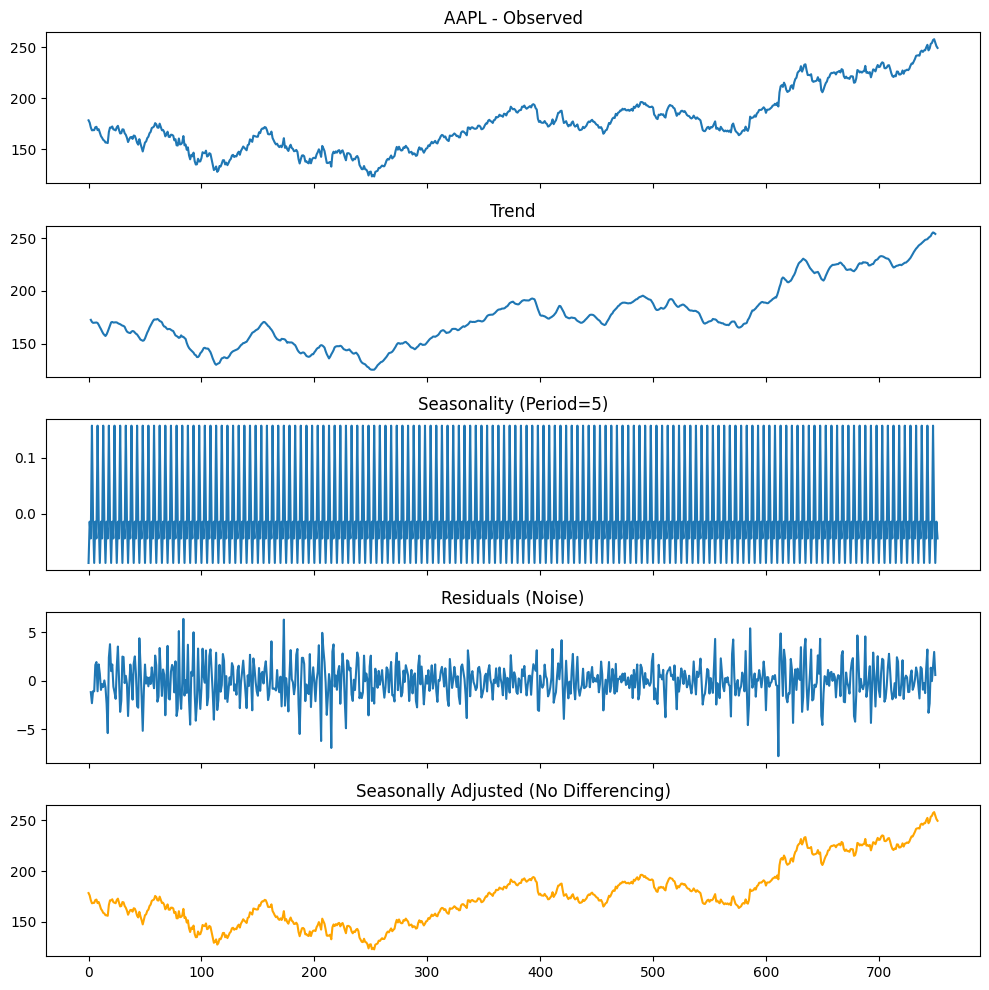


--- Stationarity Tests for AAPL Residuals ---
ADF p-value:  0.0000
KPSS p-value: 0.0521

--- Stationarity Tests for AAPL Seasonally Adjusted Series (1st Diff) ---
ADF p-value:  0.0000
KPSS p-value: 0.1000

--- ACF/PACF Diagnostics ---


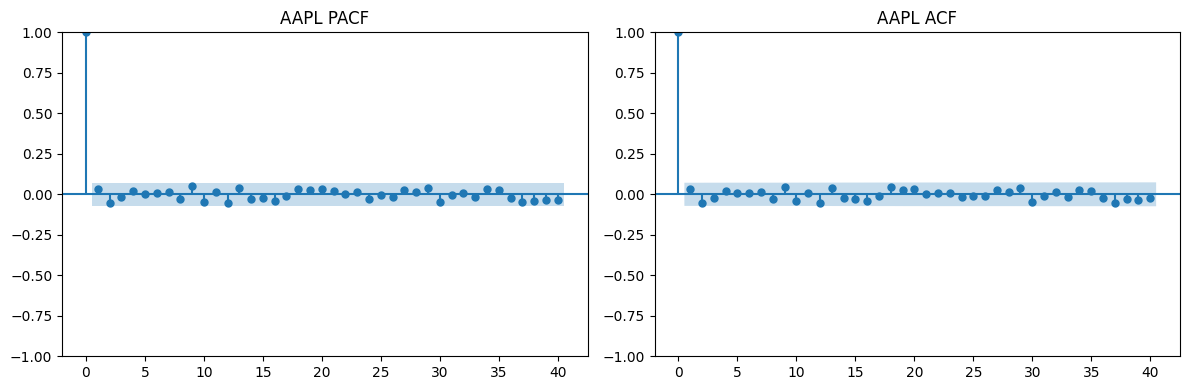

Original variance: 869.5877357357658
Seasonally adjusted variance: 869.5973128765215


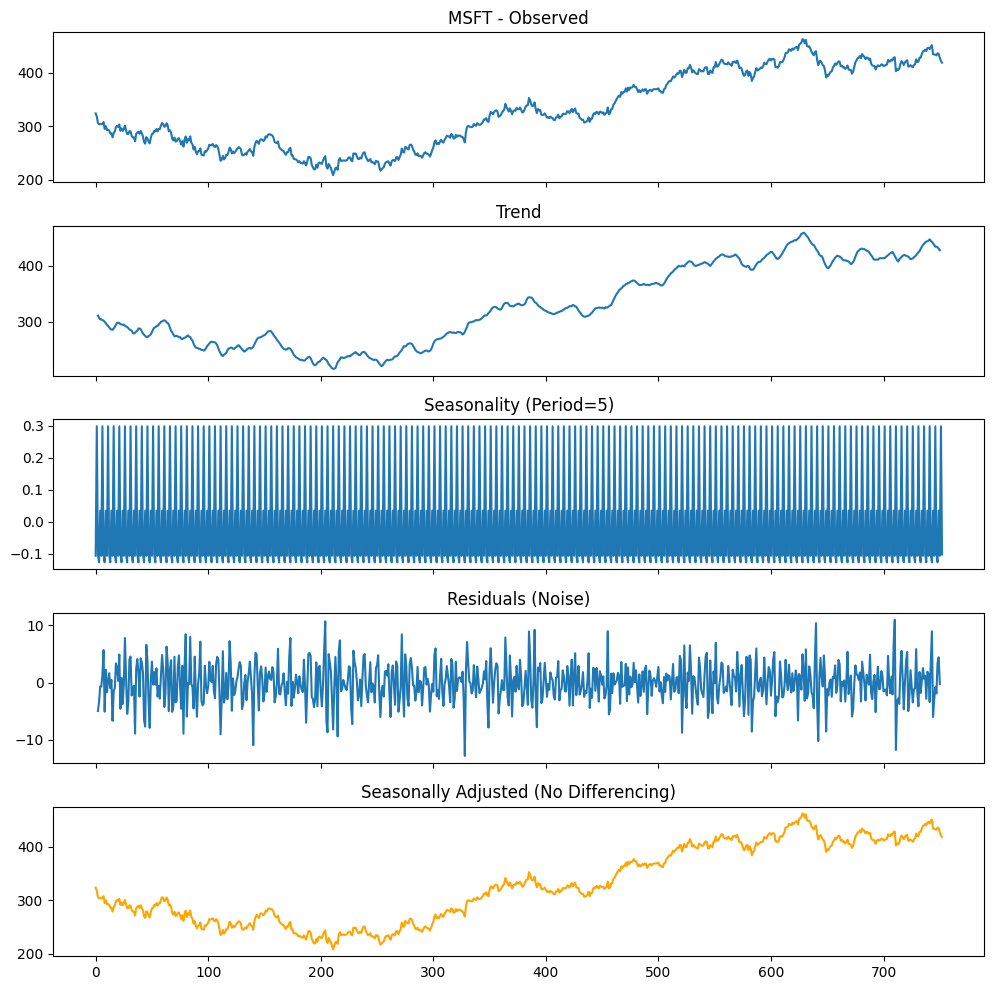


--- Stationarity Tests for MSFT Residuals ---
ADF p-value:  0.0000
KPSS p-value: 0.0417

--- Stationarity Tests for MSFT Seasonally Adjusted Series (1st Diff) ---
ADF p-value:  0.0000
KPSS p-value: 0.1000

--- ACF/PACF Diagnostics ---


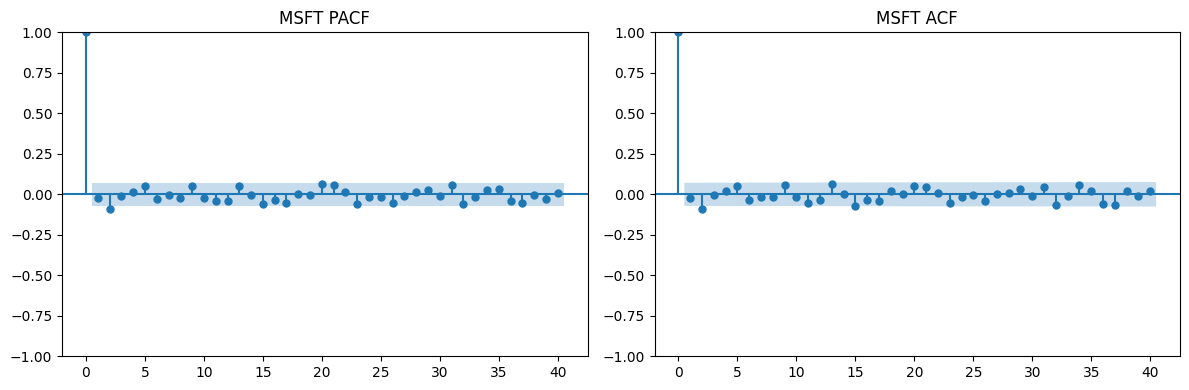

Original variance: 5046.546377414239
Seasonally adjusted variance: 5046.506544460443


In [95]:
def diagnose_stock(ticker, df, period):
    series = df['Close']
    decomp = seasonal_decompose(series.values, model='additive', period=period)

    # --- Plot Decomposition ---
    fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
    axes[0].plot(series.values); axes[0].set_title(f'{ticker} - Observed')
    axes[1].plot(decomp.trend); axes[1].set_title('Trend')
    axes[2].plot(decomp.seasonal); axes[2].set_title(f'Seasonality (Period={period})')
    axes[3].plot(decomp.resid); axes[3].set_title('Residuals (Noise)')

    # --- Plot Seasonally Adjusted Series (before differencing) ---
    sa_series = pd.Series(series.values - decomp.seasonal)
    axes[4].plot(sa_series, color='orange'); axes[4].set_title('Seasonally Adjusted (No Differencing)')
    plt.tight_layout()
    plt.show()

    # --- Residual Stationarity ---
    resid = pd.Series(decomp.resid).dropna()
    print(f"\n--- Stationarity Tests for {ticker} Residuals ---")
    adf_p = adfuller(resid)[1]
    kpss_p = kpss(resid, regression='c', nlags="auto")[1]
    print(f"ADF p-value:  {adf_p:.4f}")
    print(f"KPSS p-value: {kpss_p:.4f}")

    # --- Seasonally Adjusted Differenced Series ---
    sa_series = sa_series.dropna()
    diff_sa = sa_series.diff().dropna()

    print(f"\n--- Stationarity Tests for {ticker} Seasonally Adjusted Series (1st Diff) ---")
    adf_p_sa = adfuller(diff_sa)[1]
    kpss_p_sa = kpss(diff_sa, regression='c', nlags="auto")[1]
    print(f"ADF p-value:  {adf_p_sa:.4f}")
    print(f"KPSS p-value: {kpss_p_sa:.4f}")

    # --- ACF/PACF Diagnostics ---
    print(f"\n--- ACF/PACF Diagnostics ---")
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    plot_pacf(diff_sa, lags=40, ax=ax[0], method='ywm')
    ax[0].set_title(f"{ticker} PACF")
    plot_acf(diff_sa, lags=40, ax=ax[1])
    ax[1].set_title(f"{ticker} ACF")
    plt.tight_layout()
    plt.show()

    print("Original variance:", np.var(series))
    print("Seasonally adjusted variance:", np.var(sa_series))

for ticker in my_stocks:
    diagnose_stock(ticker, stock_data[ticker], seasonal_period)



In [96]:
def make_lagged(series, n_lags):
    s = pd.Series(series).reset_index(drop=True)
    df = pd.DataFrame({'y': s})
    for i in range(1, n_lags+1):
        df[f'lag_{i}'] = s.shift(i)
    return df.dropna()

def recursive_forecast(last_window, model, steps, feature_names):
    preds = []
    current_window = list(last_window)
    for _ in range(steps):
        input_df = pd.DataFrame([current_window], columns=feature_names)
        pred = model.predict(input_df)[0]
        preds.append(pred)
        current_window.pop(0)
        current_window.append(pred)
    return np.array(preds)


In [97]:
def train_and_validate(ticker, df, period, n_lags, steps):
    print(f"\n=== Modeling {ticker} ===")
    series = df['Close']
    decomp = seasonal_decompose(series.values, model='additive', period=period)

    seasonal = pd.Series(decomp.seasonal).dropna()
    seasonal_cycle = seasonal.iloc[-period:].values

    time_idx = np.arange(len(series)).reshape(-1, 1)
    trend_model = LinearRegression()
    trend_model.fit(time_idx, series.values)
    trend_line = trend_model.predict(time_idx)

    residuals = series.values - trend_line - decomp.seasonal
    residuals = pd.Series(residuals).fillna(0)

    split_idx = len(series) - steps
    df_lagged = make_lagged(residuals, n_lags)
    X = df_lagged.drop(columns='y')
    y = df_lagged['y']

    train_size = split_idx - n_lags
    X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]

    future_time = np.arange(len(series), len(series) + steps).reshape(-1, 1)
    future_trend = trend_model.predict(future_time)
    future_seasonal = np.tile(seasonal_cycle, int(np.ceil(steps/period)))[:steps]

    preds = {}

    try:
        arima = ARIMA(residuals.iloc[:split_idx].values, order=(5,0,5)).fit()
        p_resid_arima = arima.forecast(steps=steps)
        preds['ARIMA'] = future_trend + future_seasonal + p_resid_arima
    except:
        preds['ARIMA'] = future_trend + future_seasonal

    lr_resid = LinearRegression().fit(X_train, y_train)
    p_resid_lr = recursive_forecast(residuals.iloc[split_idx-n_lags:split_idx].values, lr_resid, steps, X_train.columns)
    preds['LinReg'] = future_trend + future_seasonal + p_resid_lr

    rf_resid = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42).fit(X_train, y_train)
    p_resid_rf = recursive_forecast(residuals.iloc[split_idx-n_lags:split_idx].values, rf_resid, steps, X_train.columns)
    preds['RF'] = future_trend + future_seasonal + p_resid_rf

    actual = series.iloc[split_idx:].values
    scores = {k: mean_squared_error(actual, v) for k, v in preds.items()}
    winner = min(scores, key=scores.get)
    print(f"  > Winner: {winner} (MSE: {scores[winner]:.4f})")

    return {
        'winner': winner,
        'preds': preds,
        'actual': actual,
        'test_index': series.index[split_idx:]
    }

results = {stock: train_and_validate(stock, stock_data[stock], seasonal_period, lags, forecast_days) for stock in my_stocks}



=== Modeling AAPL ===
  > Winner: LinReg (MSE: 114.6716)

=== Modeling MSFT ===
  > Winner: ARIMA (MSE: 358.7859)


In [98]:
def get_scalar(data_obj, index_pos):
    if hasattr(data_obj, 'values'):
        data_obj = data_obj.values
    return np.array(data_obj).flatten()[index_pos]

def get_optimal_weights(results, stocks_list, data_dict):
    expected_returns = []
    for ticker in stocks_list:
        actuals = results[ticker]['actual']
        preds = results[ticker]['preds'][results[ticker]['winner']]
        start_price = get_scalar(actuals, 0)
        end_price = get_scalar(preds, -1)
        roi = (end_price - start_price) / start_price
        n_days = len(actuals) if hasattr(actuals, '__len__') else 60
        annualized_roi = (1 + roi) ** (252 / n_days) - 1
        expected_returns.append(annualized_roi)
    
    expected_returns = np.array(expected_returns)
    price_dict = {t: data_dict[t]['Close'].values.flatten() for t in stocks_list}
    price_df = pd.DataFrame(price_dict)
    cov_matrix = price_df.pct_change().dropna().cov() * 252

    def neg_sharpe_ratio(weights):
        p_ret = np.sum(expected_returns * weights)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        return -(p_ret - 0.02) / p_vol

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0.0, 1.0) for _ in range(len(stocks_list)))

    result = sco.minimize(neg_sharpe_ratio, [1./len(stocks_list)]*len(stocks_list), 
                          method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x, expected_returns, cov_matrix


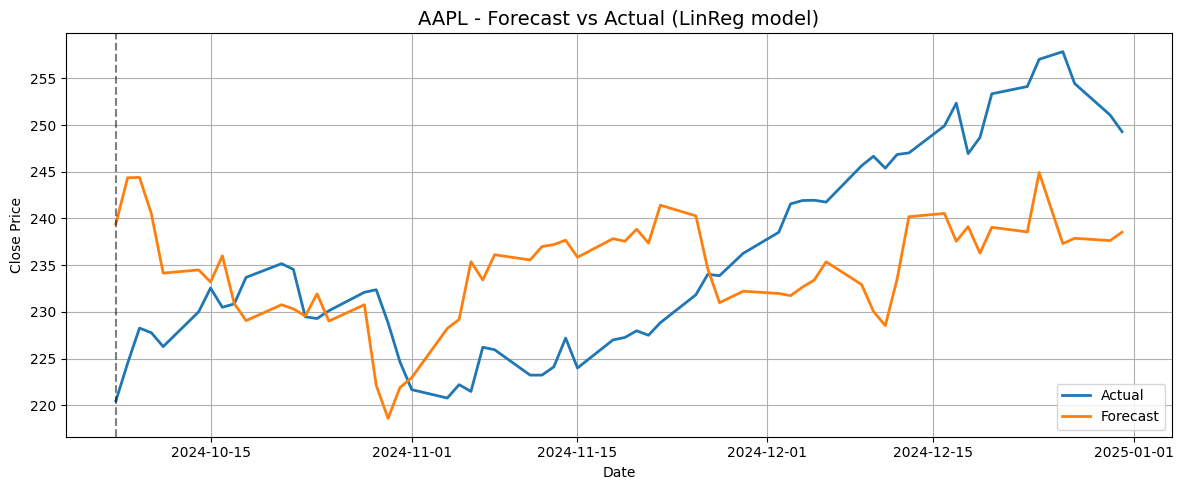

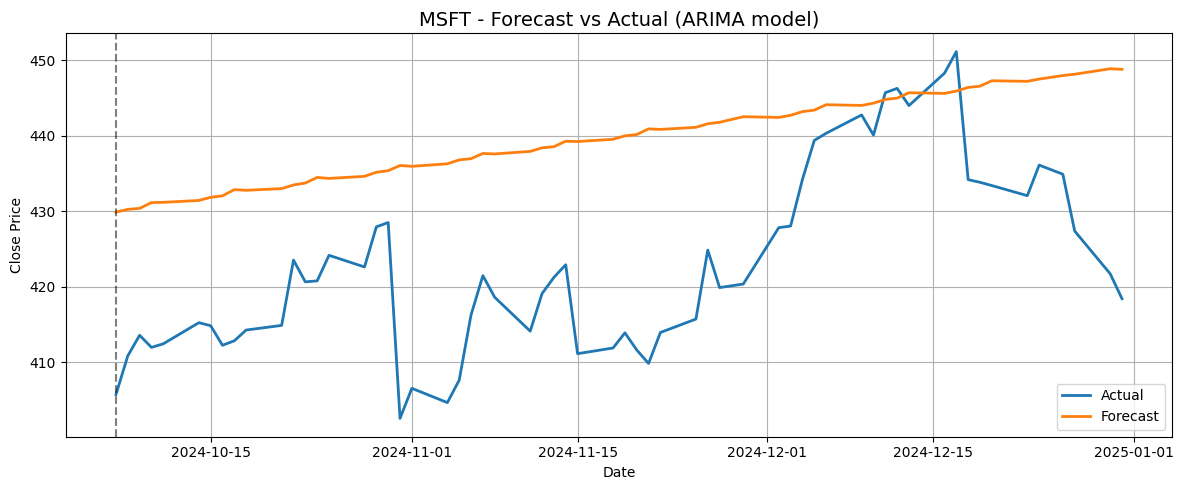

In [99]:
# 📈 Visualize Actual vs Forecasted Prices for Each Stock
def plot_test_vs_forecast(results_dict, forecast_days):
    for ticker, res in results_dict.items():
        actual = res['actual']
        forecast = res['preds'][res['winner']]
        index = res['test_index']

        plt.figure(figsize=(12, 5))
        plt.plot(index, actual, label='Actual', linewidth=2)
        plt.plot(index, forecast, label='Forecast', linewidth=2)
        plt.title(f"{ticker} - Forecast vs Actual ({res['winner']} model)", fontsize=14)
        plt.xlabel("Date")
        plt.ylabel("Close Price")
        plt.axvline(index[0], color='black', linestyle='--', alpha=0.5)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

plot_test_vs_forecast(results, forecast_days)


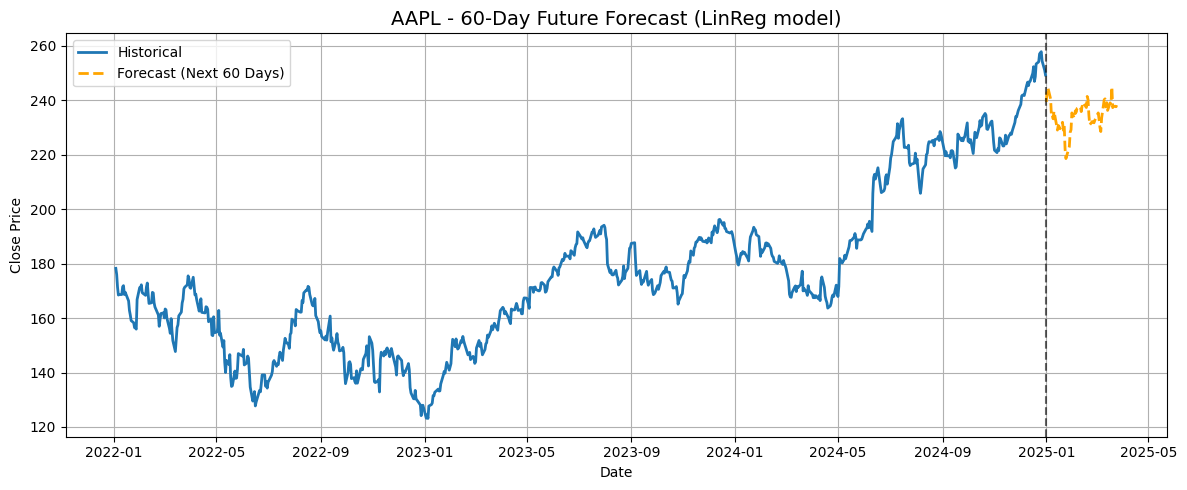

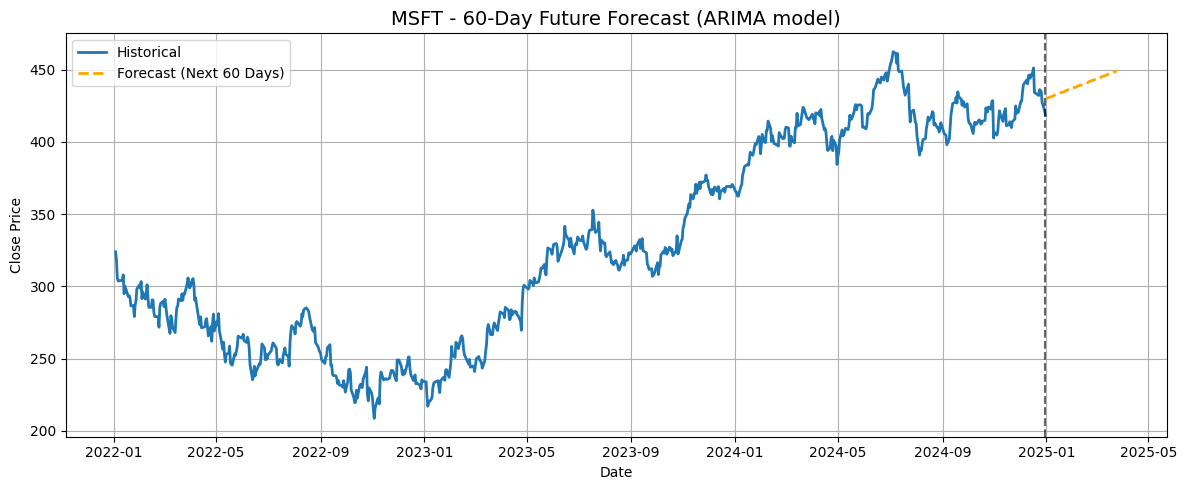

In [100]:
# 📅 Visualize Future Forecasts (60 days ahead)
def plot_future_forecasts(results_dict, stock_data_dict):
    for ticker in results_dict:
        df = stock_data_dict[ticker]
        historical_index = df.index
        last_date = historical_index[-1]
        
        forecast = results_dict[ticker]['preds'][results_dict[ticker]['winner']]
        forecast_days = len(forecast)
        future_index = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_days, freq='B')  # Business days

        plt.figure(figsize=(12, 5))
        plt.plot(historical_index, df['Close'], label='Historical', linewidth=2)
        plt.plot(future_index, forecast, label='Forecast (Next 60 Days)', linewidth=2, linestyle='--', color='orange')
        plt.title(f"{ticker} - 60-Day Future Forecast ({results_dict[ticker]['winner']} model)", fontsize=14)
        plt.xlabel("Date")
        plt.ylabel("Close Price")
        plt.axvline(last_date, color='black', linestyle='--', alpha=0.6)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

plot_future_forecasts(results, stock_data)



 FINAL TRADING REPORT (Phantom Troupe) 

1. OPTIMAL MARKOWITZ ALLOCATION:
   - AAPL: 11.43%
   - MSFT: 88.57%
PORTFOLIO EVALUATION REPORT

INDIVIDUAL STOCK PERFORMANCE:
--------------------------------------------------------------------------------
Stock    Model           Return%      Sharpe     MaxDD%     WinRate%   PF        
--------------------------------------------------------------------------------
AAPL     LinReg              13.14%      0.31     -1.40%   100.00%      inf
MSFT     ARIMA                6.74%      0.09     -5.91%   100.00%      inf
--------------------------------------------------------------------------------

Initial Capital:       $10,000.00
Final Portfolio Value: $10,736.96
Total Profit:          $736.96
Total Return:          7.37%
Sharpe Ratio:          0.11
Maximum Drawdown:      -5.22%
Volatility:            1.09%


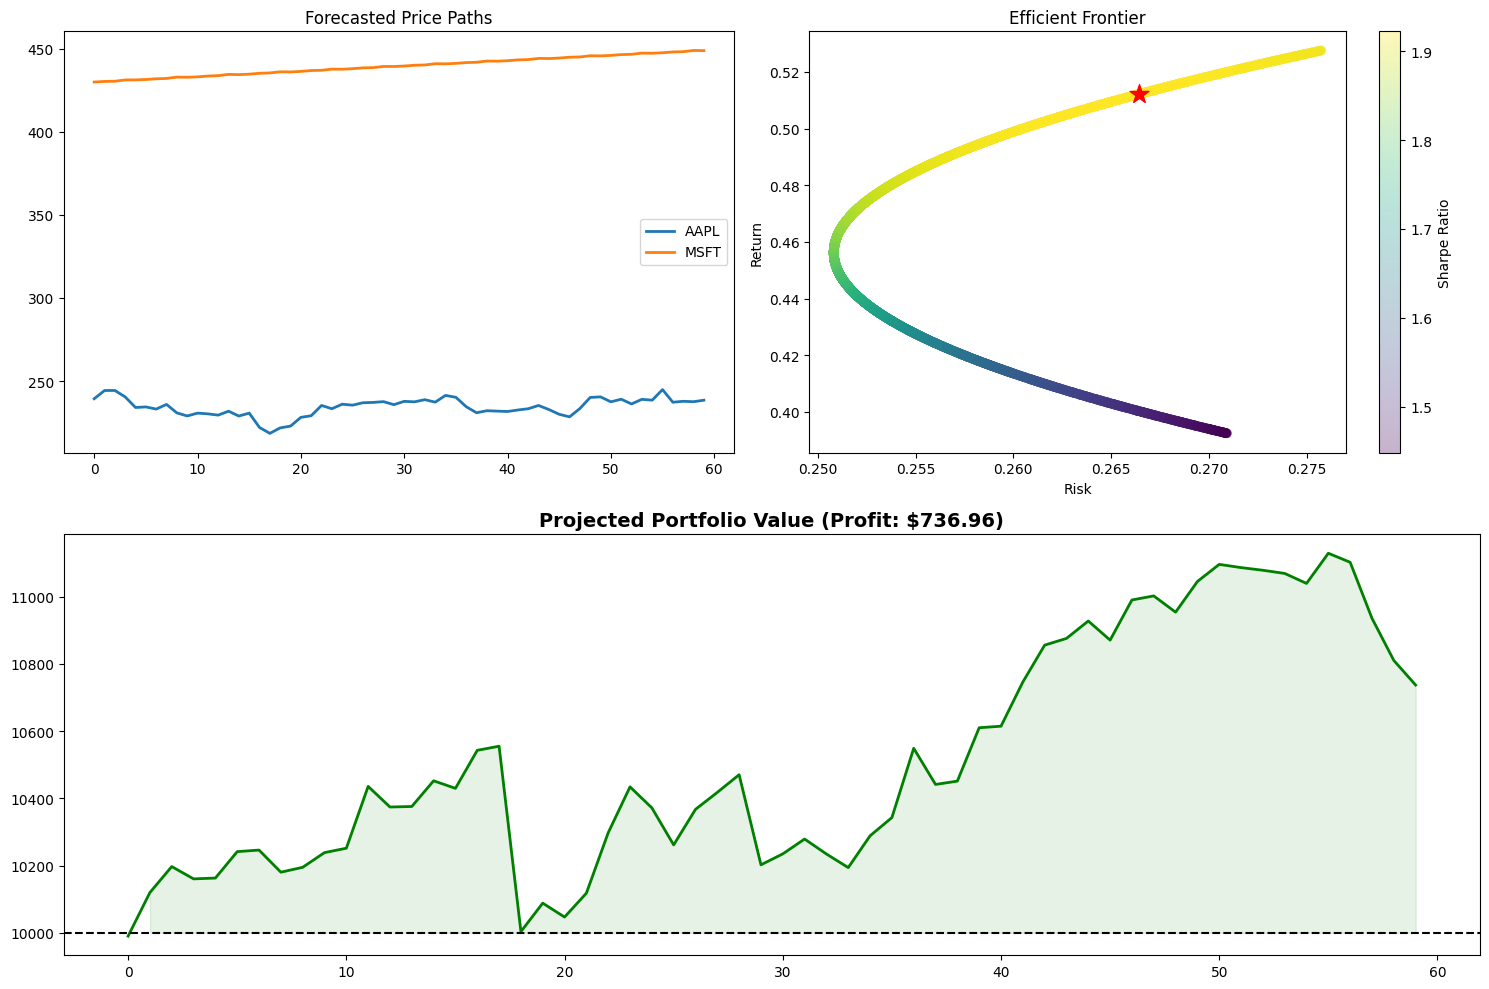


>>> ESTIMATED TOTAL PROFIT: $736.96


In [101]:
def generate_final_report(results, stocks_list, data_dict, initial_capital=10000):
    print(f"\n{'='*50}\n FINAL TRADING REPORT (Phantom Troupe) \n{'='*50}")
    
    opt_weights, exp_rets, cov_mat = get_optimal_weights(results, stocks_list, data_dict)
    allocation_dict = {ticker: round(weight, 4) for ticker, weight in zip(stocks_list, opt_weights)}
    
    print("\n1. OPTIMAL MARKOWITZ ALLOCATION:")
    for ticker, weight in allocation_dict.items():
        print(f"   - {ticker}: {weight*100:.2f}%")

    evaluator = PortfolioEvaluator(starting_capital=initial_capital, allocation=allocation_dict)
    for ticker in stocks_list:
        winner = results[ticker]['winner']
        bt = Backtest(starting_capital=initial_capital)
        bt.run_strategy(results[ticker]['actual'], results[ticker]['preds'][winner], threshold=0.01)
        evaluator.add_stock(ticker, bt, winner)

    evaluator.show_report()
    metrics = evaluator.compute_portfolio_performance()
    profit = metrics['profit_$']
    
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2)

    ax1 = fig.add_subplot(gs[0, 0])
    for ticker in stocks_list:
        preds = results[ticker]['preds'][results[ticker]['winner']]
        ax1.plot(preds, label=f"{ticker}", linewidth=2)
    ax1.set_title("Forecasted Price Paths")
    ax1.legend()

    ax2 = fig.add_subplot(gs[0, 1])
    p_rets, p_vols = [], []
    for _ in range(10000):
        weights = np.random.random(len(stocks_list))
        weights /= np.sum(weights)
        p_ret = np.sum(exp_rets * weights)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(cov_mat, weights)))
        p_rets.append(p_ret)
        p_vols.append(p_vol)

    sc = ax2.scatter(p_vols, p_rets, c=np.array(p_rets)/np.array(p_vols), cmap='viridis', alpha=0.3)
    opt_ret = np.sum(exp_rets * opt_weights)
    opt_vol = np.sqrt(np.dot(opt_weights.T, np.dot(cov_mat, opt_weights)))
    ax2.scatter(opt_vol, opt_ret, marker='*', color='red', s=200, label='Optimal')
    ax2.set_title("Efficient Frontier")
    ax2.set_xlabel("Risk")
    ax2.set_ylabel("Return")
    plt.colorbar(sc, ax=ax2, label='Sharpe Ratio')

    ax3 = fig.add_subplot(gs[1, :])
    port_values = metrics['portfolio_values']
    ax3.plot(port_values, color='green', linewidth=2)
    ax3.axhline(initial_capital, color='black', linestyle='--')
    ax3.fill_between(range(len(port_values)), initial_capital, port_values, where=[v>=initial_capital for v in port_values], color='green', alpha=0.1)
    ax3.fill_between(range(len(port_values)), initial_capital, port_values, where=[v<initial_capital for v in port_values], color='red', alpha=0.1)
    ax3.set_title(f"Projected Portfolio Value (Profit: ${profit:,.2f})", fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    print(f"\n>>> ESTIMATED TOTAL PROFIT: ${profit:,.2f}")

generate_final_report(results, my_stocks, stock_data, capital)
